# Movie Genre Classification with NLP

## Version
**V1 — Baseline (TF-IDF + Logistic Regression)**

### Objective
Build a baseline NLP model to classify movie genres from movie overviews using a traditional machine learning approach.

### Dataset
- TMDB 5000 Movies

### Model
- TF-IDF (max_features=5000, unigram)
- Logistic Regression

### Evaluation Metric
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

In [4]:
import pandas as pd
from pathlib import Path

# ==========================
# Project Configuration
# ==========================

PROJECT_ROOT = Path.cwd().parent.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

MODEL_DIR = PROJECT_ROOT / "v1-tfidf-logreg" / "models"
OUTPUT_DIR = PROJECT_ROOT / "v1-tfidf-logreg" / "outputs"

# Membuat folder jika belum ada
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Load Dataset

In [5]:
df = pd.read_csv(RAW_DATA_DIR / "tmdb_5000_movies.csv")

df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

## Exploratory Data Analysis (EDA)

In [7]:
df.shape

(4803, 20)

In [8]:
df.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')

In [9]:
df[["title", "overview", "genres"]].head()

,title,overview,genres
0,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""..."
2,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."
3,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam..."
4,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."


In [10]:
df[["overview", "genres"]].isnull().sum()

overview    3
genres      0
dtype: int64

In [11]:
df[df["overview"].isnull()]

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
2656,15000000,"[{""id"": 18, ""name"": ""Drama""}]",NaN,370980,"[{""id"": 717, ""name"": ""pope""}, {""id"": 5565, ""na...",it,Chiamatemi Francesco - Il Papa della gente,NaN,0.738646,"[{""name"": ""Taodue Film"", ""id"": 45724}]","[{""iso_3166_1"": ""IT"", ""name"": ""Italy""}]",2015-12-03,0,NaN,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,NaN,Chiamatemi Francesco - Il Papa della gente,7.3,12
4140,2,"[{""id"": 99, ""name"": ""Documentary""}]",NaN,459488,"[{""id"": 6027, ""name"": ""music""}, {""id"": 225822,...",en,"To Be Frank, Sinatra at 100",NaN,0.050625,"[{""name"": ""Eyeline Entertainment"", ""id"": 60343}]","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}]",2015-12-12,0,NaN,[],Released,NaN,"To Be Frank, Sinatra at 100",0.0,0
4431,913000,"[{""id"": 99, ""name"": ""Documentary""}]",NaN,292539,[],de,Food Chains,NaN,0.795698,[],[],2014-04-26,0,83.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,Food Chains,7.4,8


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["title"].duplicated().sum()

np.int64(3)

In [14]:
df[df["title"].duplicated(keep=False)][["title", "release_date", "overview"]]

,title,release_date,overview
972,The Host,2013-03-22,A parasitic alien soul is injected into the bo...
1359,Batman,1989-06-23,The Dark Knight of Gotham City begins his war ...
2877,The Host,2006-07-27,Gang-du is a dim-witted man working at his fat...
3647,Out of the Blue,1980-05-01,Dennis Hopper is a hard-drinking truck driver ...
3693,Out of the Blue,2006-10-12,Ordinary people find extraordinary courage in ...
4267,Batman,1966-07-30,The Dynamic Duo faces four super-villains who ...


In [15]:
import ast

# ubah string JSON menjadi list of dict
df["genres_parsed"] = df["genres"].apply(ast.literal_eval)

df[["title", "genres_parsed"]].head()

,title,genres_parsed
0,Avatar,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam..."
1,Pirates of the Caribbean: At World's End,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."
2,Spectre,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam..."
3,The Dark Knight Rises,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam..."
4,John Carter,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam..."


In [16]:
df["genre_count"] = df["genres_parsed"].apply(len)
df["genre_count"].describe()

count    4803.000000
mean        2.531751
std         1.120955
min         0.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         7.000000
Name: genre_count, dtype: float64

In [17]:
df["genre_count"].value_counts().sort_index()

genre_count
0      28
1     900
2    1490
3    1525
4     636
5     187
6      33
7       4
Name: count, dtype: int64

In [18]:
from collections import Counter

all_genres = []
for genres in df["genres_parsed"]:
    for g in genres:
        all_genres.append(g["name"])

genre_counts = Counter(all_genres)
genre_counts.most_common(10)

[('Drama', 2297),
 ('Comedy', 1722),
 ('Thriller', 1274),
 ('Action', 1154),
 ('Romance', 894),
 ('Adventure', 790),
 ('Crime', 696),
 ('Science Fiction', 535),
 ('Horror', 519),
 ('Family', 513)]

## Data Cleaning

In [19]:
df_clean = df.copy()

df_clean.shape

(4803, 22)

In [20]:
df_clean = df_clean.dropna(subset=["overview"])

df_clean["overview"].isnull().sum()

np.int64(0)

In [21]:
df_clean.shape

(4800, 22)

In [22]:
df_clean = df_clean[df_clean["genre_count"] > 0]

df_clean["genre_count"].value_counts().sort_index()

genre_count
1     897
2    1490
3    1525
4     636
5     187
6      33
7       4
Name: count, dtype: int64

In [23]:
def get_primary_genre(genres):
    return genres[0]["name"]

df_clean["genre"] = df_clean["genres_parsed"].apply(get_primary_genre)

df_clean[["title", "genre"]].head()

,title,genre
0,Avatar,Action
1,Pirates of the Caribbean: At World's End,Adventure
2,Spectre,Action
3,The Dark Knight Rises,Action
4,John Carter,Action


In [24]:
df_model = df_clean[["title", "overview", "genre"]].copy()

df_model.head()

,title,overview,genre
0,Avatar,"In the 22nd century, a paraplegic Marine is di...",Action
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",Adventure
2,Spectre,A cryptic message from Bond’s past sends him o...,Action
3,The Dark Knight Rises,Following the death of District Attorney Harve...,Action
4,John Carter,"John Carter is a war-weary, former military ca...",Action


In [25]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4772 entries, 0 to 4802
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     4772 non-null   object
 1   overview  4772 non-null   object
 2   genre     4772 non-null   object
dtypes: object(3)
memory usage: 149.1+ KB


## Text Preprocessing

In [26]:
df_model["overview"] = df_model["overview"].str.lower()

df_model["overview"].iloc[0]

'in the 22nd century, a paraplegic marine is dispatched to the moon pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.'

In [27]:
import re

def preprocess_text(text):
    # lowercase
    text = text.lower()

    # remove ordinal numbers (22nd, 1st, 3rd, dst.)
    text = re.sub(r"\b\d+(st|nd|rd|th)\b", "", text)

    # remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [28]:
df_model["overview"] = df_model["overview"].apply(preprocess_text)

In [29]:
sample = "Hello!!! I'm 22nd years old. My room number is 404."

print(preprocess_text(sample))

hello im years old my room number is


## Final Dataset Check

In [30]:
df_model.isnull().sum()

title       0
overview    0
genre       0
dtype: int64

In [31]:
(df_model["overview"].str.len() == 0).sum()

np.int64(1)

In [32]:
df_model[df_model["overview"].str.len() == 0]

,title,overview,genre
4401,The Helix... Loaded,,Action


In [33]:
# hapus overview kosong
df_model = df_model[df_model["overview"].str.len() > 0].copy()

# threshold minimal jumlah data per genre
MIN_SAMPLES = 30

# hitung distribusi genre
genre_distribution = df_model["genre"].value_counts()

# ambil genre yang memenuhi threshold
valid_genres = genre_distribution[genre_distribution >= MIN_SAMPLES].index

# filter dataset
df_model = df_model[df_model["genre"].isin(valid_genres)].copy()

# reset index
df_model.reset_index(drop=True, inplace=True)

In [34]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

print(f"Jumlah data       : {len(df_model)}")
print(f"Jumlah genre      : {df_model['genre'].nunique()}")
print(f"Overview kosong   : {(df_model['overview'].str.len() == 0).sum()}")

print("\nDistribusi Genre")
print(df_model["genre"].value_counts())

print("\nRata-rata panjang overview")
print(f"{df_model['overview'].str.split().str.len().mean():.2f} kata")

DATASET SUMMARY
Jumlah data       : 4689
Jumlah genre      : 15
Overview kosong   : 0

Distribusi Genre
genre
Drama              1206
Comedy             1042
Action              753
Adventure           339
Horror              300
Crime               195
Thriller            194
Animation           123
Fantasy             117
Romance             106
Science Fiction      96
Documentary          87
Family               56
Mystery              41
Music                34
Name: count, dtype: int64

Rata-rata panjang overview
51.68 kata


In [35]:
df_model.to_csv(
    PROCESSED_DATA_DIR / "movies_clean.csv",
    index=False
)

## Train-Test Split

In [36]:
from sklearn.model_selection import train_test_split

# Feature dan target
X = df_model["overview"]
y = df_model["genre"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
print("=" * 50)
print("TRAIN TEST SPLIT")
print("=" * 50)

print(f"Training data : {len(X_train)}")
print(f"Testing data  : {len(X_test)}")

print("\nDistribusi Train")
print(y_train.value_counts())

TRAIN TEST SPLIT
Training data : 3751
Testing data  : 938

Distribusi Train
genre
Drama              965
Comedy             833
Action             602
Adventure          271
Horror             240
Crime              156
Thriller           155
Animation           98
Fantasy             94
Romance             85
Science Fiction     77
Documentary         70
Family              45
Mystery             33
Music               27
Name: count, dtype: int64


In [38]:
print("\nDistribusi Test")
print(y_test.value_counts())


Distribusi Test
genre
Drama              241
Comedy             209
Action             151
Adventure           68
Horror              60
Thriller            39
Crime               39
Animation           25
Fantasy             23
Romance             21
Science Fiction     19
Documentary         17
Family              11
Mystery              8
Music                7
Name: count, dtype: int64


## Feature Extraction

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=False,
            max_features=5000,
            ngram_range=(1, 1)
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

## Model Training

In [40]:
pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,False
,preprocessor,None
,tokenizer,None


In [41]:
y_pred = pipeline.predict(X_test)

In [42]:
result = pd.DataFrame({
    "Overview": X_test.values,
    "Actual": y_test.values,
    "Prediction": y_pred
})

result.head(10)

,Overview,Actual,Prediction
0,a former government operative renowned for his...,Action,Action
1,john winger an indolent sad sack in his s impu...,Action,Drama
2,harry ron and hermione return to hogwarts for ...,Adventure,Comedy
3,a young lion cub named simba cant wait to be k...,Family,Adventure
4,a husband and wife try to reinvigorate their r...,Thriller,Drama
5,minutes focuses on a college professor pacino ...,Crime,Drama
6,amalia is an adolescent girl who is caught in ...,Drama,Drama
7,estranged twin brothers one a con man the othe...,Action,Drama
8,rocket singh salesman of the year is the somet...,Drama,Drama
9,back in middle school after summer vacation gr...,Family,Comedy


## Model Evaluation

In [43]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("=" * 50)
print(f"Accuracy : {accuracy:.4f}")
print("=" * 50)

print("\nClassification Report\n")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Accuracy : 0.3934

Classification Report

                 precision    recall  f1-score   support

         Action       0.39      0.49      0.43       151
      Adventure       0.33      0.04      0.08        68
      Animation       0.00      0.00      0.00        25
         Comedy       0.40      0.56      0.46       209
          Crime       0.00      0.00      0.00        39
    Documentary       0.00      0.00      0.00        17
          Drama       0.39      0.69      0.50       241
         Family       0.00      0.00      0.00        11
        Fantasy       0.00      0.00      0.00        23
         Horror       0.53      0.15      0.23        60
          Music       0.00      0.00      0.00         7
        Mystery       0.00      0.00      0.00         8
        Romance       0.00      0.00      0.00        21
Science Fiction       0.00      0.00      0.00        19
       Thriller       0.00      0.00      0.00        39

       accuracy                           0.

<Figure size 1200x1200 with 0 Axes>

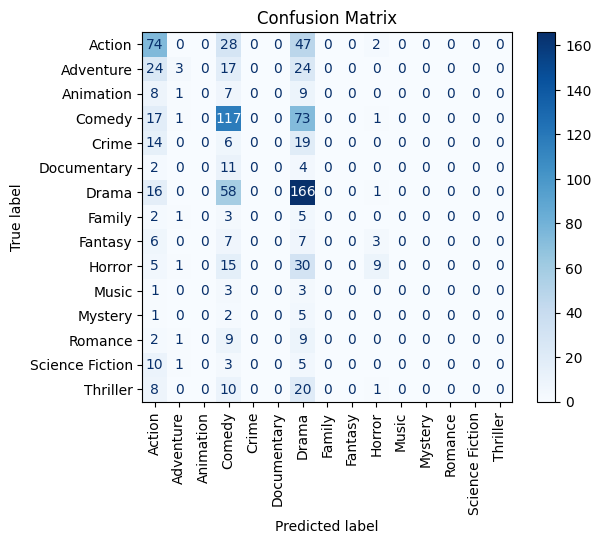

In [44]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(12, 12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=90,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [45]:
print(pipeline)

Pipeline(steps=[('tfidf', TfidfVectorizer(lowercase=False, max_features=5000)),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])


In [46]:
pd.Series(y_pred).value_counts()

Drama        426
Comedy       296
Action       190
Horror        17
Adventure      9
Name: count, dtype: int64

In [47]:
len(pipeline.named_steps["tfidf"].vocabulary_)

5000

In [48]:
df_model.head()

,title,overview,genre
0,Avatar,in the century a paraplegic marine is dispatch...,Action
1,Pirates of the Caribbean: At World's End,captain barbossa long believed to be dead has ...,Adventure
2,Spectre,a cryptic message from bonds past sends him on...,Action
3,The Dark Knight Rises,following the death of district attorney harve...,Action
4,John Carter,john carter is a warweary former military capt...,Action


In [49]:
X_train.iloc[0]

'lowlevel bureaucrat sam lowry escapes the monotony of his daytoday life through a recurring daydream of himself as a virtuous hero saving a beautiful damsel investigating a case that led to the wrongful arrest and eventual death of an innocent man instead of wanted terrorist harry tuttle he meets the woman from his daydream and in trying to help her gets caught in a web of mistaken identities mindless bureaucracy and lies'

In [50]:
y_train.iloc[0]

'Comedy'

## Save Artifacts

In [51]:
import joblib

joblib.dump(
    pipeline,
    MODEL_DIR / "movie_genre_classifier.pkl"
)


['d:\\movie-genre-classification\\v1-tfidf-logreg\\models\\movie_genre_classifier.pkl']

In [52]:
report = classification_report(
    y_test,
    y_pred,
    zero_division=0
)

with open(
    OUTPUT_DIR / "classification_report.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(report)

In [53]:
import json
metrics = {
    "accuracy": round(accuracy_score(y_test, y_pred), 4)
}

with open(
    OUTPUT_DIR / "metrics.json",
    "w"
) as f:
    json.dump(metrics, f, indent=4)


In [54]:
sample_predictions = result.copy()

sample_predictions.to_csv(
    OUTPUT_DIR / "sample_predictions.csv",
    index=False
)

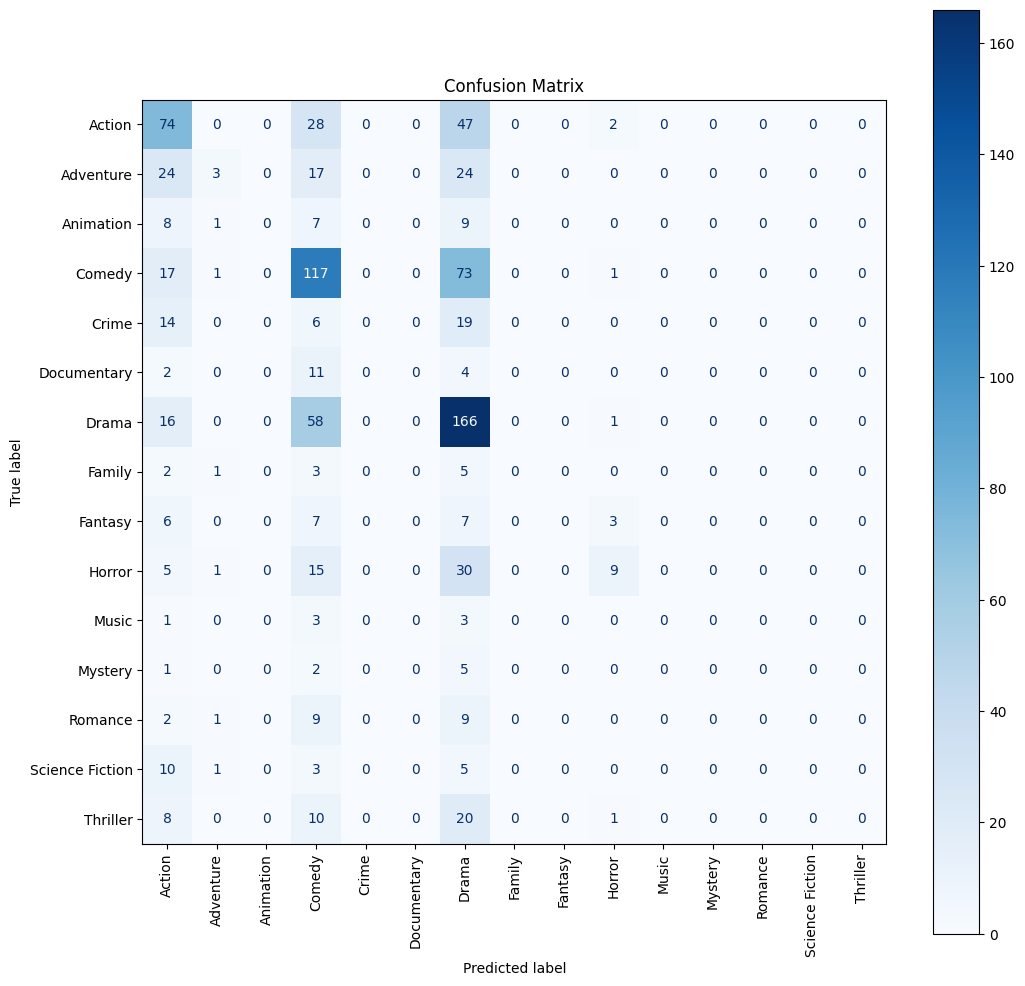

In [55]:
fig, ax = plt.subplots(figsize=(12, 12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=90,
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix")

plt.savefig(
    OUTPUT_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Conclusion

The baseline model achieved an accuracy of **39.34%**.

Although the model successfully classifies the dominant genres, it struggles with minority classes such as Music, Mystery, and Documentary. This baseline will be used as the reference for future improvements in V2.